In [1]:
%matplotlib inline

import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as snb

from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

In [2]:
def generate_samples(key, m, K, num_samples, jitter=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################
    
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter*jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)
    
    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples

@dataclass
class Hyperparameters(object):
    kappa:          float = 1.0 # magnitude, positive scalar (default=1.0)
    lengthscale:    float = 1.0 # characteristic lengthscale, positive scalar (default=1.0)
    sigma:          float = 1.0 # noise std. dev., positive scalar (default=1.0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappa={self.kappa:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'

hyperparameters = Hyperparameters(kappa=2.0, lengthscale=0.5)
hyperparameters

# in the code below tau represents the distance between to input points, i.e. tau = ||x_n - x_m||.
def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

def matern12(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-tau/hyperparameters.lengthscale)

def matern32(tau, hyperparameters):
    return hyperparameters.kappa**2*(1 + jnp.sqrt(3)*tau/hyperparameters.lengthscale)*jnp.exp(-jnp.sqrt(3)*tau/hyperparameters.lengthscale)

class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
        
        # squared exponential covariance function
        K = self.kernel_fun(dists, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K
def plot_with_uncertainty(ax, Xp, gp, color='r', color_samples='b', title="", num_samples=0, seed=0):
    
    mu, Sigma = gp.predict_y(Xp)
    mean, std = mu.ravel(), jnp.sqrt(jnp.diag(Sigma))

    # random seed
    key = random.PRNGKey(seed)

    # plot distribution
    ax.plot(Xp, mean, color=color, label='Mean')
    ax.plot(Xp, mean + 2*std, color=color, linestyle='--')
    ax.plot(Xp, mean - 2*std, color=color, linestyle='--')
    ax.fill_between(Xp.ravel(), mean - 2*std, mean + 2*std, color=color, alpha=0.25, label='95% interval')
    
    # generate samples
    if num_samples > 0:
        fs = gp.posterior_samples(key, Xstar, num_samples)
        ax.plot(Xp, fs[:,0], color=color_samples, alpha=.25, label="$f(x)$ samples")
        ax.plot(Xp, fs[:, 1:], color=color_samples, alpha=.25)
    ax.set_title(title)
    

class GaussianProcessRegression(object):

    def __init__(self, X, y, kernel, hyperparameters, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.kernel = kernel
        self.jitter = jitter
        self.set_hyperparameters(hyperparameters)
        self.check_dimensions()

    def check_dimensions(self):
        N, D = self.X.shape
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"

    def set_hyperparameters(self, hyper):
        self.hyperparameters = hyper
        
    def posterior_samples(self, key, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                key              -- jax random key for controlling the random number generator
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(key, mu.ravel(), Sigma, num_samples)
        
        ##############################################
        # End of solution
        ##############################################

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples
        
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        mu, Sigma = self.predict_f(Xstar)
        Sigma = Sigma + self.hyperparameters.sigma**2 * jnp.identity(len(mu))
        
        ##############################################
        # End of solution
        ##############################################

        return mu, Sigma

    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        k = self.kernel.construct_kernel(Xstar, self.X, self.hyperparameters, jitter=self.jitter)
        K = self.kernel.construct_kernel(self.X, self.X, self.hyperparameters, jitter=self.jitter)
        Kstar = self.kernel.construct_kernel(Xstar, Xstar, self.hyperparameters, jitter=self.jitter)
        
        # Compute C matrix
        C = K + self.hyperparameters.sigma**2*jnp.identity(len(self.X)) 

        # computer mean and Sigma
        mu = jnp.dot(k, jnp.linalg.solve(C, self.y))
        Sigma = Kstar - jnp.dot(k, jnp.linalg.solve(C, k.T))
        
        ##############################################
        # End of solution
        ##############################################

        # sanity check for dimensions
        assert (mu.shape == (len(Xstar), 1)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, 1), but actual shape was {mu.shape}. Please check implementation"
        assert (Sigma.shape == (len(Xstar), len(Xstar))), f"The shape of the posterior Sigma seems wrong. Expected ({len(Xstar)}, {len(Xstar)}), but actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    def log_marginal_likelihood(self, hyperparameters):
        """ 
            evaluate the log marginal likelihood p(y) given the hyperparaemters 

            Arguments:
                hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
            """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare kernels
        K = self.kernel.construct_kernel(self.X, self.X, hyperparameters)
        C = K + hyperparameters.sigma**2*jnp.identity(self.N)

        # compute Cholesky decomposition
        L = jnp.linalg.cholesky(C)
        v = jnp.linalg.solve(L, self.y)

        # compute log marginal likelihood
        logdet_term = jnp.sum(jnp.log(jnp.diag(L)))
        quad_term =  0.5*jnp.sum(v**2)
        const_term = -0.5*self.N*jnp.log(2*jnp.pi)

        return const_term - logdet_term - quad_term


        
        ##############################################
        # End of solution
        ##############################################
        
# instantiate  kernel objects
#kernel = StationaryIsotropicKernel(squared_exponential)

# specify hyperparameters
#hyper = Hyperparameters(kappa=1.0, lengthscale=1.0, sigma=0.5)

# instantiate GP without data (hence, posterior=prior) and with data
#gp_prior = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel, hyper)
#gp_post = GaussianProcessRegression(Xtrain, ytrain, kernel, hyper)




# Example usage

<h3> Data <h3>

In [3]:
Xtrain = jnp.array([[-2.17], [1.99], [0.57], [-3.01], [-1.16], [3.30], [-4.85], [-0.86]])
ytrain = jnp.array([0.88, 0.46, -0.06, 0.98, 0.45, 0.88, -0.66, 0.05]).reshape(-1,1)
Xstar = jnp.linspace(-5, 4, 100)[:, None]

assert(Xtrain.shape[0] == ytrain.shape[0])

<h3> Model <h3>

In [4]:

kernel = StationaryIsotropicKernel(squared_exponential)

hyper_init = Hyperparameters(kappa=0.7, lengthscale=(1/2) * jnp.sqrt(2), sigma=1/5)
gp = GaussianProcessRegression(X =  Xtrain, y = ytrain, kernel = kernel, hyperparameters=hyper_init)


<h3> Plot data <h3>

(-2.0, 2.0)

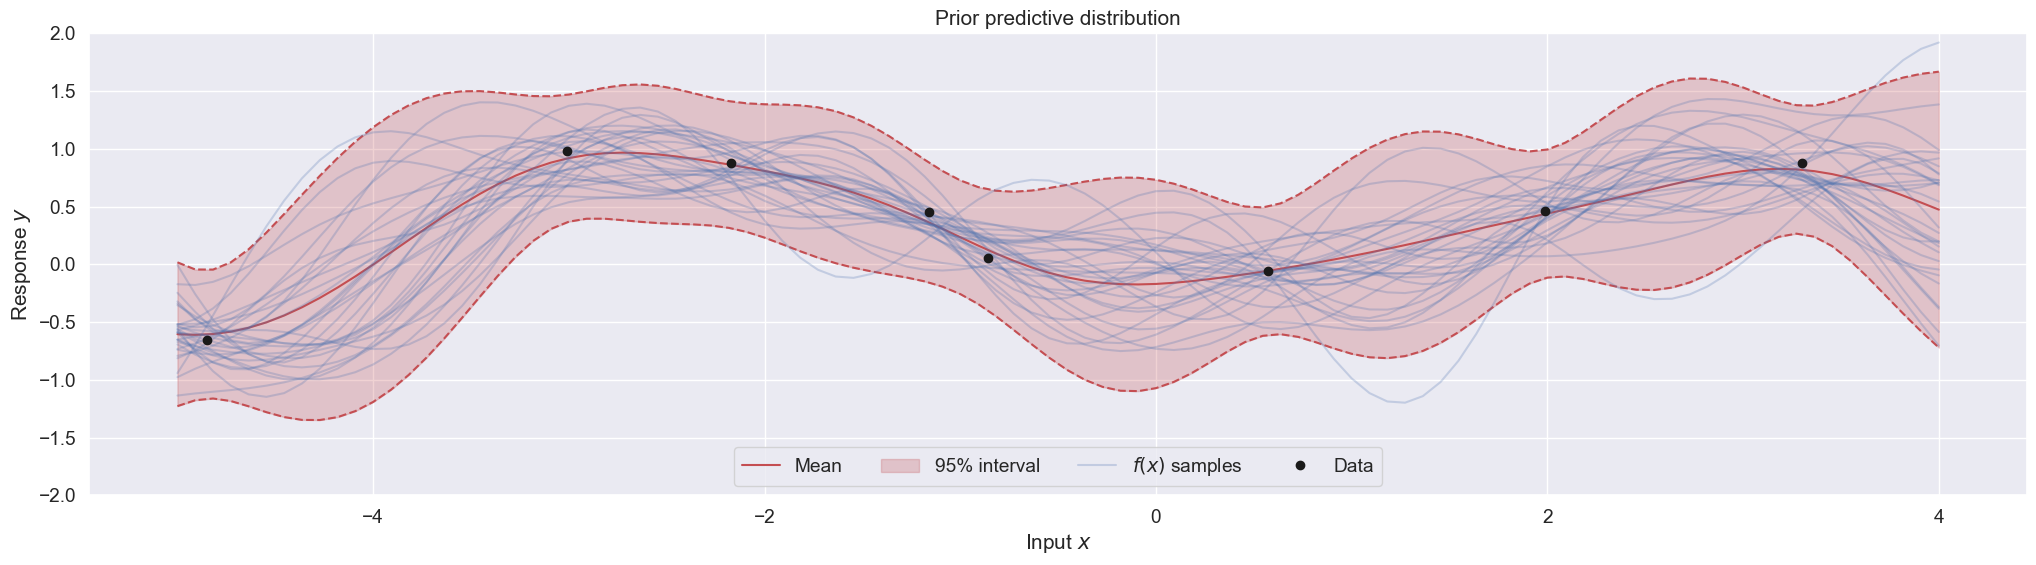

In [5]:
def plot_data(ax):
    ax.plot(Xtrain, ytrain, 'k.', markersize=12, label='Data')
    ax.grid(True)
    ax.set_xlabel('Input $x$')
    ax.set_ylabel('Response $y$')
    ax.legend()


fig, ax = plt.subplots(1, figsize=(25, 6))
plot_with_uncertainty(ax, Xstar, gp, title='Prior predictive distribution', num_samples=30)
plot_data(ax)
ax.legend(loc='lower center', ncol=4)
ax.set_ylim((-2, 2))

<h3>Find posterior predictive<h3>

In [6]:
Xstar = jnp.array([[227]])
gp.predict_y(Xstar)

(Array([[0.]], dtype=float64), Array([[0.53000001]], dtype=float64))

In [7]:
gp.log_marginal_likelihood(hyper_init)

Array(-6.65121142, dtype=float64)

In [8]:
Xstar = jnp.array([[1]])
gp.predict_f(Xstar), gp.predict_y(Xstar)

((Array([[0.07054075]], dtype=float64), Array([[0.13887566]], dtype=float64)),
 (Array([[0.07054075]], dtype=float64), Array([[0.17887566]], dtype=float64)))

# New kernel

In [9]:
l = 1 / jnp.sqrt(2)
Xtrain = jnp.array([[-2.17], [1.99], [0.57], [-3.01], [-1.16], [3.30], [-4.85], [-0.86]])
k2 = lambda x1,x2: (1 + jnp.abs(x1 - x2) / (2*l**2))**(-1) + x1*x2
cov_dic = []

for x in Xtrain:
    cov_dic.append(k2(x,-1))

In [10]:

def exercise_kernel(X1,X2,hyperparameters):
    K = [[hyperparameters.kappa0**2 + hyperparameters.kappa1**2 * x1 * x2 + hyperparameters.kappa2**2 * jnp.exp((x1 - x2)**2 / (2 * hyperparameters.lengthscale**2)) for x2 in X2] for x1 in X1]
    return jnp.array(K)

class ExerciseKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        #dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
        
        # squared exponential covariance function
        K = self.kernel_fun(X1,X2, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K
    
@dataclass
class Hyperparameters(object):
    kappa0:         float = 1.0 # magnitude, positive scalar (default=1.0)
    kappa1:         float = 1.0
    kappa2:         float = 1.0
    lengthscale:    float = 1.0 # characteristic lengthscale, positive scalar (default=1.0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappa={self.kappa:3.2f}, lengthscal'

In [11]:
hyper_init = Hyperparameters(kappa0=5,kappa1 = 0, kappa2 = 1, lengthscale=(1/2) * jnp.sqrt(2))

kernel = ExerciseKernel(exercise_kernel)

gp = GaussianProcessRegression(jnp.zeros((0, 1)), jnp.zeros((0, 1)), kernel, hyper_init)

Xstar = jnp.linspace(-6, 6, 100)[:, None]
Xstar

Array([[-6.        ],
       [-5.87878788],
       [-5.75757576],
       [-5.63636364],
       [-5.51515152],
       [-5.39393939],
       [-5.27272727],
       [-5.15151515],
       [-5.03030303],
       [-4.90909091],
       [-4.78787879],
       [-4.66666667],
       [-4.54545455],
       [-4.42424242],
       [-4.3030303 ],
       [-4.18181818],
       [-4.06060606],
       [-3.93939394],
       [-3.81818182],
       [-3.6969697 ],
       [-3.57575758],
       [-3.45454545],
       [-3.33333333],
       [-3.21212121],
       [-3.09090909],
       [-2.96969697],
       [-2.84848485],
       [-2.72727273],
       [-2.60606061],
       [-2.48484848],
       [-2.36363636],
       [-2.24242424],
       [-2.12121212],
       [-2.        ],
       [-1.87878788],
       [-1.75757576],
       [-1.63636364],
       [-1.51515152],
       [-1.39393939],
       [-1.27272727],
       [-1.15151515],
       [-1.03030303],
       [-0.90909091],
       [-0.78787879],
       [-0.66666667],
       [-0